In [ ]:
from ultralytics import YOLO
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from piq import KID
import torch
import os
from glob import glob
import random




def read_image(path):
    with rasterio.open(path) as src:
        image = src.read()
    return image[:3].transpose(1, 2, 0)  # Convert to HWC format


    
def match_histogram(source, target):
    matched = np.zeros_like(source)
    for c in range(source.shape[2]):
        src_band = source[:, :, c].flatten()
        tgt_band = target[:, :, c].flatten()

        src_values, src_counts = np.unique(src_band, return_counts=True)
        tgt_values, tgt_counts = np.unique(tgt_band, return_counts=True)

        src_cdf = np.cumsum(src_counts).astype(np.float64) / src_counts.sum()
        tgt_cdf = np.cumsum(tgt_counts).astype(np.float64) / tgt_counts.sum()

        interp_tgt_values = np.interp(src_cdf, tgt_cdf, tgt_values)
        matched[:, :, c] = np.interp(src_band, src_values, interp_tgt_values).reshape(source[:, :, c].shape)

    return matched.astype(source.dtype)


def percentile_stretch(image, lower=2, upper=98):
    stretched = np.zeros_like(image)
    for c in range(image.shape[2]):
        # do not consider 0 values for percentile calculation
        non_zero_pixels = image[:, :, c][image[:, :, c] > 0]
        if len(non_zero_pixels) == 0:
            stretched[:, :, c] = image[:, :, c]
            continue

        p_low, p_high = np.percentile(non_zero_pixels, [lower, upper])
        stretched[:, :, c] = np.clip((image[:, :, c] - p_low) * 255.0 / (p_high - p_low), 0, 255)

    return stretched.astype(np.uint8)


def delete_non_data(tile, threshold=0.95):
    """
    Returns True if the tile contains valid data, False if it is mostly 'No Data'.
    """   
   
    no_data_pixels = np.all(tile == 0, axis=-1)
    no_data_fraction = np.mean(no_data_pixels)
    
    return no_data_fraction < threshold



def cut_into_tiles(image, tile_size=64):
    tiles = []
    for i in range(0, image.shape[0], tile_size):
        for j in range(0, image.shape[1], tile_size):
            tile = image[i:i+tile_size, j:j+tile_size, :]
            
            # Check for correct dimensions
            if tile.shape[0] == tile_size and tile.shape[1] == tile_size:
                # NEW: Only keep the tile if it contains data
                if delete_non_data(tile):
                    tiles.append(tile)
                    
    print(f"Cut image into {len(tiles)} tiles of size {tile_size}x{tile_size} (discarded empty areas)")
    return np.array(tiles)






def extract_yolo_features(tiles, model):
    embeddings = []
    for tile in tiles:
        results = model.embed(tile, imgsz=640)
        embeddings.append(results[0].cpu().numpy())
        print(f"Extracted features from tile {len(embeddings)}/{len(tiles)}")  
    return embeddings





In [5]:
import torchvision.transforms as T
from transformers import AutoModel
from transformers.modeling_utils import PreTrainedModel
from PIL import Image




# SatDINO: DINO pretrained on fMoW satellite imagery (strakaj/SatDINO)
# Options: strakajk/satdino-vit_small-16 | strakajk/satdino-vit_small-8 | strakajk/satdino-vit_base-16
SATDINO_MODEL = "strakajk/satdino-vit_base-16" 

# fMoW normalization stats (as used in SatDINO training)
FMOW_MEAN = (0.3826, 0.3525, 0.3051)
FMOW_STD  = (0.1598, 0.1474, 0.1384)

def _get_all_tied_weights_keys(self):
    val = getattr(self, "_tied_weights_keys", None)
    if val is None:
        return {}
    return val
PreTrainedModel.all_tied_weights_keys = property(_get_all_tied_weights_keys)


def build_satdino_transform():
    """
    Preprocessing transform expected by SatDINO:
    resize to 224x224, convert to float tensor [0,1], normalize with fMoW stats.
    """
    return T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),                        # (H,W,3) uint8 -> (3,H,W) float [0,1]
        T.Normalize(mean=FMOW_MEAN, std=FMOW_STD),
    ])

def tile_to_rgb_uint8(tile):
    """
    Convert a (C, H, W) multi-band tile to a (H, W, 3) uint8 RGB image
    using bands 0, 1, 2 with 2-98% percentile stretch.
    """
    if tile.shape[0] >= 3:
        rgb = tile[:3].astype(np.float32)
    else:
        rgb = np.stack([tile[0].astype(np.float32)] * 3)

    # normalize using mean and std

    stretched = np.zeros((3,) + rgb.shape[1:], dtype=np.uint8)
    for c in range(3):
        band = rgb[c]
        p2, p98 = np.percentile(band, 2), np.percentile(band, 98)
        if p98 > p2:
            band = (band - p2) / (p98 - p2)
            # band = band / 255.0
        else:
            band = band - band.min()
            if band.max() > 0:
                band = band / band.max()
        stretched[c] = np.clip(band * 255, 0, 255).astype(np.uint8)
    
    return np.transpose(stretched, (1, 2, 0))  # (H, W, 3)

def extract_satdino_features(tiles, batch_size=32):
    """
    Extract per-tile CLS token embeddings using strakaj/SatDINO.

    Args:
        tiles:      (N, C, H, W) numpy array of multi-band raw tiles
        batch_size: tiles to process in one forward pass

    Returns:
        features:   (N, embed_dim) numpy array  -- 384-d for ViT-S
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Loading SatDINO ({SATDINO_MODEL}) on {device}...")

    model = AutoModel.from_pretrained(SATDINO_MODEL, trust_remote_code=True)
    model.to(device)
    model.eval()

    transform = build_satdino_transform()
    all_features = []

    for start in range(0, len(tiles), batch_size):
        batch_tiles = tiles[start:start + batch_size]
        print(f"  Encoding tiles {start}-{start + len(batch_tiles) - 1} / {len(tiles)}")

        # Convert each raw tile -> uint8 RGB PIL image -> transformed tensor
        tensors = []
        for tile in batch_tiles:
            rgb_uint8 = tile_to_rgb_uint8(tile)          # (H, W, 3) uint8
            pil_img = Image.fromarray(rgb_uint8, "RGB")
            tensors.append(transform(pil_img))            # (3, 224, 224)

        batch_tensor = torch.stack(tensors).to(device)   # (B, 3, 224, 224)

        with torch.inference_mode():
            # SatDINO forward returns the CLS token: shape (B, embed_dim)
            features = model(batch_tensor)

        all_features.append(features.float().cpu().numpy())

    return np.concatenate(all_features, axis=0)  # (N, embed_dim)

/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
# Parameters
dir_ss2 = "/home/thomas/Documents/code/pleiades-boat-detection/data/scoring/diff/PLN" # simulé
dir_s2 = "/home/thomas/Documents/code/pleiades-boat-detection/data/scoring/diff/PL" # real
tile_size = 64
nb_features = 500

# List images
list_ss2 = sorted(glob(os.path.join(dir_ss2, "**/*.tif"), recursive=True))
list_s2 = sorted(glob(os.path.join(dir_s2, "**/*.tif"), recursive=True))

# Cut into tiles
# MAYBE
target = read_image(list_s2[-2])  # Use S2 image as histogram matching target
ss2_tiles = [cut_into_tiles(match_histogram(read_image(path), target), tile_size) for path in list_ss2]
s2_tiles = [cut_into_tiles(read_image(path), tile_size) for path in list_s2]

# SATDINOOOOOOO
# Extract features on random tiles from each dataset
ss2_features = []
s2_features = []
for tiles in ss2_tiles:
    random_tiles = random.sample(list(tiles), min(nb_features, len(tiles)))
    ss2_features.append(extract_satdino_features(random_tiles, batch_size=64))
for tiles in s2_tiles:
    random_tiles = random.sample(list(tiles), min(nb_features, len(tiles)))
    s2_features.append(extract_satdino_features(random_tiles, batch_size=64))

KeyboardInterrupt: 

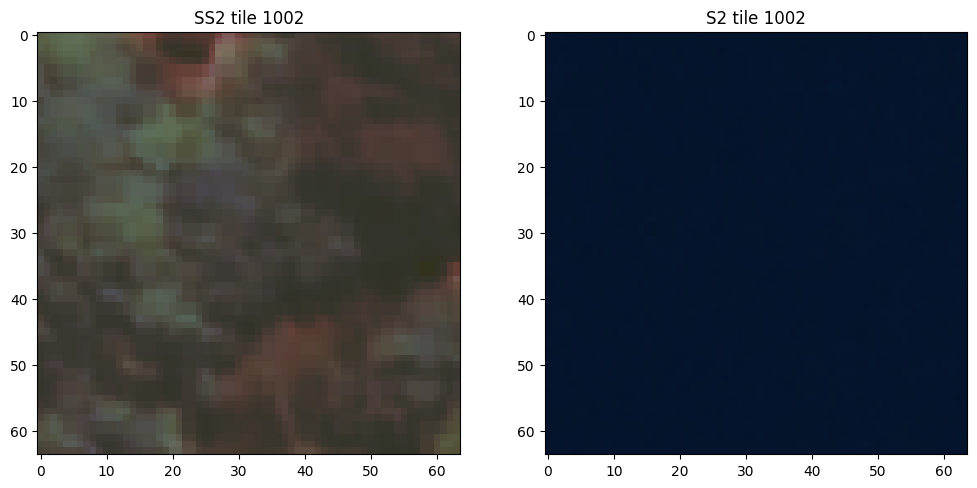

In [26]:
tile_id = 1002
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(ss2_tiles[0][tile_id])
plt.title(f"SS2 tile {tile_id}")
plt.subplot(1,2,2)
plt.imshow(s2_tiles[0][tile_id])
plt.title(f"S2 tile {tile_id}")
plt.show()

In [27]:
# Prepare datasets for KID computation
datasets = {}
for i, path in enumerate(list_ss2):
    datasets[f"SS2_{i}"] = ss2_features[i]
    print(f"id: SS2_{i}\t features: {len(ss2_features[i])}\t filename: {os.path.basename(path)}")
for i, path in enumerate(list_s2):
    datasets[f"S2_{i}"] = s2_features[i]
    print(f"id: S2_{i}\t features: {len(s2_features[i])}\t filename: {os.path.basename(path)}")

# Define KID metric with appropriate parameters
metric = KID(
    degree=3,
    gamma=None,
    coef0=1,
    var_at_m=None,
    average=True,
    n_subsets=50,
    subset_size=100,  # Use 100 random subsets for KID computation
    ret_var=True
)

# Kernel Inception Distance (KID) computation
nb_datasets = len(datasets)
results = np.zeros((nb_datasets, nb_datasets))
for i, (name_i, emb_i) in enumerate(datasets.items()):
    for j, (name_j, emb_j) in enumerate(datasets.items()):
        x_feats = torch.from_numpy(np.array(emb_i)).float()
        y_feats = torch.from_numpy(np.array(emb_j)).float()
        result = metric(x_feats, y_feats)
        # print(f"KID({name_i}, {name_j}) = {result[0].item():.4f} ± {result[1].item():.4f}")
        results[i, j] = result[0].item()  # Store the KID value, ignoring variance



id: SS2_0	 features: 500	 filename: GEN_bottom.tif
id: SS2_1	 features: 500	 filename: PLN_bottom.tif
id: S2_0	 features: 500	 filename: 1_URN_AIP_DATA_pwh_1812e700-cf39-3cd4-a26c-3d3db1b8b67e_V1.tif
id: S2_1	 features: 500	 filename: 2_URN_AIP_DATA_pwh_1812e700-cf39-3cd4-a26c-3d3db1b8b67e_V1.tif
id: S2_2	 features: 500	 filename: 3_URN_AIP_DATA_pwh_1812e700-cf39-3cd4-a26c-3d3db1b8b67e_V1.tif
id: S2_3	 features: 500	 filename: 4_URN_AIP_DATA_pwh_1812e700-cf39-3cd4-a26c-3d3db1b8b67e_V1.tif
id: S2_4	 features: 500	 filename: IMG_PHR1A_P_202306170727036_ORT_6725788101-1_R1C1.tif
id: S2_5	 features: 500	 filename: IMG_PHR1B_MS_202105060713458_ORT_6268927101-2_R1C1.tif
id: S2_6	 features: 500	 filename: PL_real_top.tif
id: S2_7	 features: 500	 filename: 1_URN_AIP_DATA_pwh_1812e700-cf39-3cd4-a26c-3d3db1b8b67e_V1.tif
id: S2_8	 features: 500	 filename: 2_URN_AIP_DATA_pwh_1812e700-cf39-3cd4-a26c-3d3db1b8b67e_V1.tif
id: S2_9	 features: 500	 filename: 3_URN_AIP_DATA_pwh_1812e700-cf39-3cd4-a26c-3d

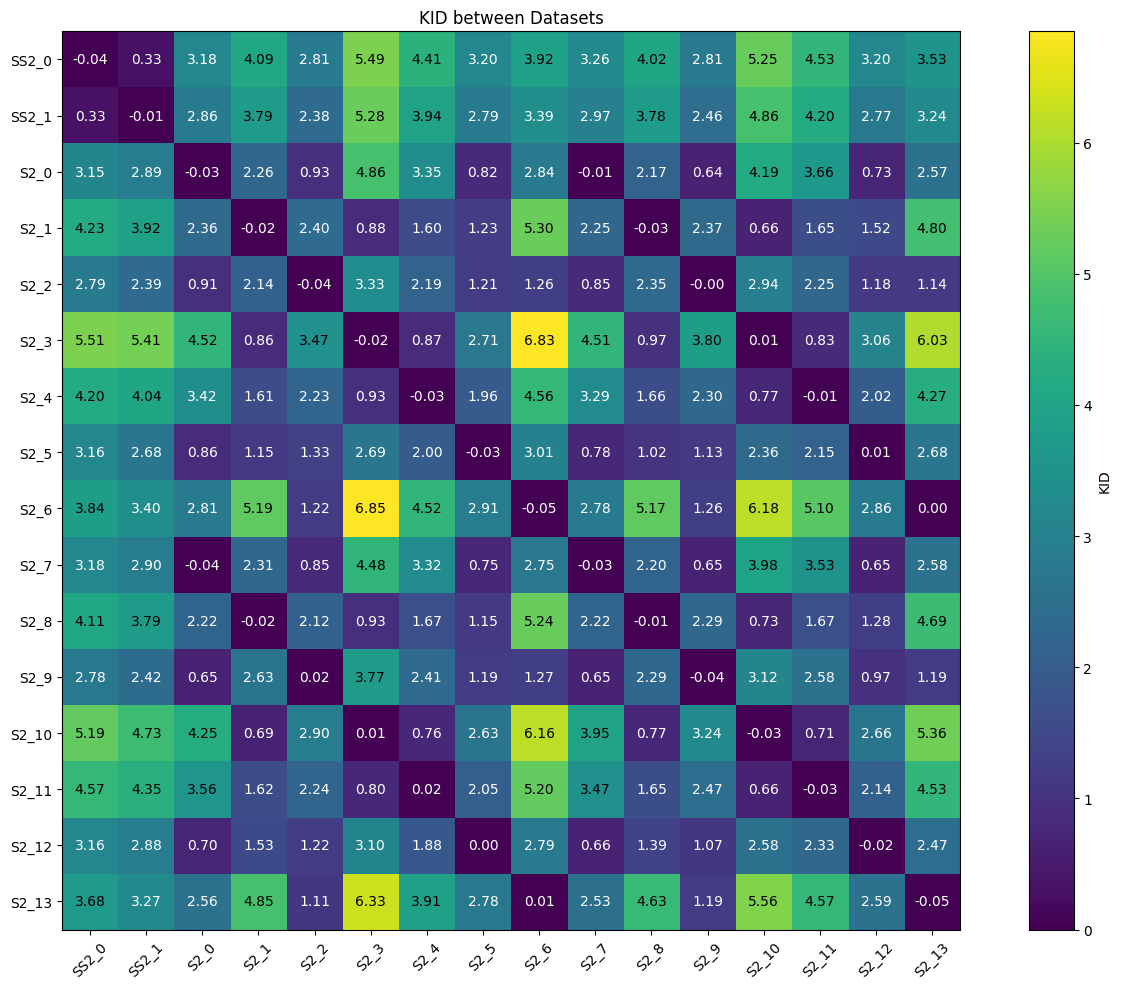

In [28]:
# Visualization
plt.figure(figsize=(14, 10))
plt.imshow(results, cmap="viridis", vmin=0, vmax=np.max(results))
plt.colorbar(label="KID")
plt.xticks(range(nb_datasets), datasets.keys(), rotation=45)
plt.yticks(range(nb_datasets), datasets.keys())
for i in range(nb_datasets):
    for j in range(nb_datasets):
        plt.text(j, i, f"{results[i, j]:.2f}", ha="center", va="center", color="white" if results[i, j] < np.max(results) / 2 else "black")
plt.title("KID between Datasets")
plt.tight_layout()
plt.show()

In [7]:
# get average score for each dataset against all s2 datasets except itself
avg_scores = {}
for i, name_i in enumerate(datasets.keys()):
    avg_scores[name_i] = np.mean([results[i, j] for j, name_j in enumerate(datasets.keys()) if name_j.startswith("S2") and j != i])

print("\nAverage KID scores against S2 datasets:")
for name, score in avg_scores.items():
    print(f"{name}: {score:.4f}")


Average KID scores against S2 datasets:
SS2_0: 7.0616
SS2_1: 5.5497
SS2_2: 4.4648
SS2_3: 2.2377
SS2_4: 2.3058
S2_0: 1.3270
S2_1: 1.1410
S2_2: 0.9061
S2_3: 1.1177
S2_4: 1.3319
S2_5: 2.3731
S2_6: 2.1736
S2_7: 1.4946
S2_8: 1.2779
S2_9: 1.6152
